In [1]:
#!git clone https://github.com/lqiang67/rectified-flow.git
%cd rectified-flow/

/Users/saptarshiroy/Library/CloudStorage/OneDrive-TheUniversityofTexasatAustin/My Drive/rectified_flow/clustRF/rectified-flow


In [2]:
import torch
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import torch.distributions as dist
import gmm 
from rectified_flow.utils import set_seed
from rectified_flow.utils import visualize_2d_trajectories_plotly
from rectified_flow.datasets.toy_gmm import TwoPointGMM

from rectified_flow.rectified_flow import RectifiedFlow
from rectified_flow.models.toy_mlp import MLPVelocityConditioned, MLPVelocity

set_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [151]:
import numpy as np
def geom_timegrid_generator(NUM_STEPS, delta):
    geom_timegrid = np.zeros(NUM_STEPS + 1)
    h = np.exp(2/(NUM_STEPS-2) * np.log(1/(2 * delta))) - 1.0
    # First partition [0, 1/2]
    geom_timegrid[0] = 0
    geom_timegrid[1] = delta
    for j in range(2, NUM_STEPS // 2 + 1):
        geom_timegrid[j] = (1 + h) * geom_timegrid[j - 1]

    # Second partition [1/2, 1]
    geom_timegrid[NUM_STEPS] = 1.0
    geom_timegrid[NUM_STEPS - 1] = 1.0 - delta
    for j in range(NUM_STEPS - 2, NUM_STEPS // 2 - 1, -1):
        geom_timegrid[j] = 1.0 - (1 + h) * (1.0 - geom_timegrid[j + 1])
    geom_timegrid = torch.tensor(geom_timegrid, device = device)

    return geom_timegrid


lin_timegrid_generator = lambda NUM_STEPS: torch.linspace(0,1 , NUM_STEPS+1).to(device)

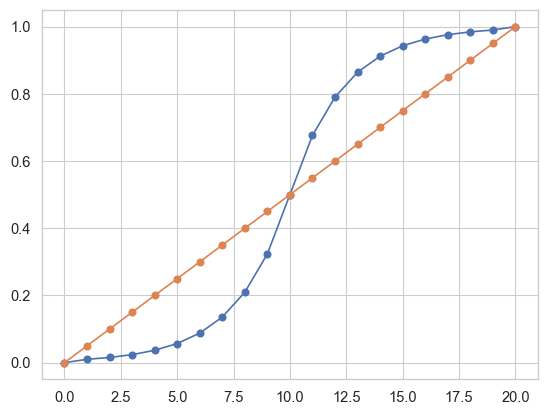

In [161]:
geom_grid = geom_timegrid_generator(20, delta=0.01)
plt.plot(range(geom_grid.shape[0]), geom_grid.cpu().numpy(), marker='o')
lin_grid = lin_timegrid_generator(20)
plt.plot(range(lin_grid.shape[0]), lin_grid.cpu().numpy(), marker='o')
plt.show()

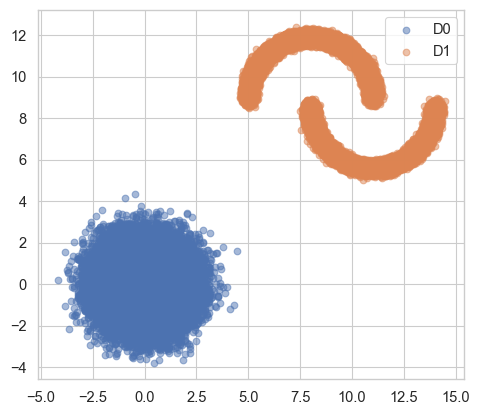

In [142]:
from sklearn.datasets import make_moons
from data_generator import generate_data
#####################################
n_samples = 50000
INPUT_DIM = 100
RANK = 8
CENTER = torch.ones(INPUT_DIM) * 8.0
TYPE = 'two_moons'  # 'low_rank_Gaussian' or 'two_moons'
#####################################

pi_0 = dist.MultivariateNormal(torch.zeros(INPUT_DIM, device=device), torch.eye(INPUT_DIM, device=device))
D0 = pi_0.sample([n_samples])  
D1 = generate_data(TYPE, n_samples, INPUT_DIM, RANK, CENTER, device=device)




plt.scatter(D0[:, 0].cpu().numpy(), D0[:, 1].cpu().numpy(), alpha=0.5, label='D0')
plt.scatter(D1[:, 0].cpu().numpy(), D1[:, 1].cpu().numpy(), alpha=0.5, label='D1')
plt.legend()
#plt.xlim(-5, 18)
#plt.ylim(-8, 8)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


# Generating two moon dataset for training
       


In [143]:
D0.shape, D1.shape

(torch.Size([50000, 100]), torch.Size([50000, 100]))

Epoch [1/10000], loss: 65.4530
Epoch [501/10000], loss: 1.1246
Epoch [1001/10000], loss: 1.1066
Epoch [1501/10000], loss: 1.1054
Epoch [2001/10000], loss: 1.0785
Epoch [2501/10000], loss: 1.0763
Epoch [3001/10000], loss: 1.0572
Epoch [3501/10000], loss: 1.0581
Epoch [4001/10000], loss: 1.0405
Epoch [4501/10000], loss: 1.0026
Epoch [5001/10000], loss: 0.9927
Epoch [5501/10000], loss: 0.9586
Epoch [6001/10000], loss: 0.9259
Epoch [6501/10000], loss: 0.9085
Epoch [7001/10000], loss: 0.8808
Epoch [7501/10000], loss: 0.8456
Epoch [8001/10000], loss: 0.8329
Epoch [8501/10000], loss: 0.8173
Epoch [9001/10000], loss: 0.7918
Epoch [9501/10000], loss: 0.7717


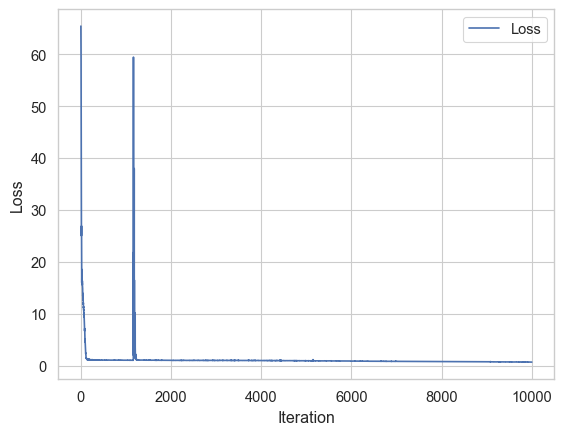

In [144]:
from RFmodules import rf_trainer
from rectified_flow.models.toy_mlp import MLPVelocity
from RFmodules import VelocityNet

straight_rf = RectifiedFlow(
    data_shape=(INPUT_DIM,),
    velocity_field=VelocityNet(INPUT_DIM, h_dim=128).to(device), # MLPVelocity(INPUT_DIM, hidden_sizes = [128] * 6).to(device)
    interp="straight",
    source_distribution=pi_0,
    device=device,
)

losses =rf_trainer(straight_rf, D0, D1, 'loss', num_epochs=10000)
plt.plot(losses, label= 'Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()

In [ ]:
from RFsampler_modules import MyEulerSampler, MytrueEulerSampler
NUM_STEPS = 500
NUM_SAMPLES = 2000

euler_sampler_lin = MyEulerSampler(
    rectified_flow=straight_rf,
    time_grid = lin_timegrid_generator(NUM_STEPS),
    num_samples= NUM_SAMPLES,
)

euler_sampler_geom = MyEulerSampler(
    rectified_flow=straight_rf,
    time_grid = geom_timegrid_generator(NUM_STEPS, delta=1/INPUT_DIM),
    num_samples= NUM_SAMPLES,
)



# Sample method 1)
# Will use the default num_steps and num_samples previously set in the Sampler class
traj1_geom = euler_sampler_geom.sample_loop(seed=100)
traj1_lin = euler_sampler_lin.sample_loop(seed=100)



from rectified_flow.samplers import SDESampler

sde_sampler_sphere_lin = SDESampler(
    rectified_flow=straight_rf,
	time_grid = lin_timegrid_generator(NUM_STEPS),
	num_samples= NUM_SAMPLES,
    noise_scale = lambda t: 1/(t + 1e-6),
    noise_method = 'euler',
    ode_method = 'euler'
)

sde_sampler_sphere_geom = SDESampler(
    rectified_flow=straight_rf,
	time_grid = geom_timegrid_generator(NUM_STEPS),
	num_samples= NUM_SAMPLES,
    noise_scale = lambda t: 1/(t + 1e-6),
    noise_method = 'euler',
    ode_method = 'euler'
)
traj2_geom = sde_sampler_sphere_geom.sample_loop(seed=100)
traj2_lin = sde_sampler_sphere_lin.sample_loop(seed=100)

In [146]:
# visualize the trajectories by tracing the trajectories
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import pandas as pd
from matplotlib.lines import Line2D

def draw_plot_sns(traj, z1, M=5, num_traj = 100, second_coord = 1,sampler_label = 'Deterministic Sampler', save_pdf=True):
    sns.set_theme(
        style="whitegrid",
        context="paper",
        font_scale=1.2
    )

    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.set_xlim(-0.5*M, M)
    ax.set_ylim(-0.5*M, 0.5*M)

    # -------- prepare data --------
    p1 = z1[:900].cpu().numpy() # plot only 900 points from p1 for better visualization
    p0 = traj[0].cpu().numpy()
    gen = traj[-1].cpu().numpy()

    df = pd.DataFrame(
        {
            "x": np.concatenate([p1[:, 0], p0[:, 0], gen[:, 0]]),
            "y": np.concatenate([p1[:, second_coord], p0[:, second_coord], gen[:, second_coord]]),
            "dist": (
                ["$p_1$"] * len(p1)
                + ["$p_0$"] * len(p0)
                + ["Generated"] * len(gen)
            ),
        }
    )

    # -------- seaborn scatter --------
    sns.scatterplot(
        data=df,
        x="x",
        y="y",
        hue="dist",
        alpha=0.35,
        s=20,
        ax=ax,
        legend=False
    )

    # -------- trajectories (matplotlib) --------
    traj_particles = torch.stack(traj).cpu().numpy()
    for i in range(min(num_traj, traj_particles.shape[1])):
        ax.plot(
            traj_particles[:, i, 0],
            traj_particles[:, i, second_coord],
            color="gray",
            alpha=0.15,
            linewidth=0.8
        )

    # -------- opaque legend --------
    palette = sns.color_palette()

    legend_elements = [
        Line2D([0], [0], marker='o', linestyle='',
               label=r'$p_1$', markerfacecolor=palette[0], markersize=8),
        Line2D([0], [0], marker='o', linestyle='',
               label=r'$p_0$', markerfacecolor=palette[1], markersize=8),
        Line2D([0], [0], marker='o', linestyle='',
               label='Generated', markerfacecolor=palette[2], markersize=8),
    ]

    ax.legend(
        handles=legend_elements,
        frameon=True,
        fancybox=True,
        framealpha=0.95,
        loc="upper left"
    )

    ax.set_title(sampler_label, pad=8)
    ax.set_aspect("equal", adjustable="box")
    sns.despine(trim=True)
    plt.tight_layout()
    if save_pdf:
        plt.savefig(sampler_label.replace(" ", "_") + '.pdf', format='pdf', bbox_inches='tight', dpi = 300)
    


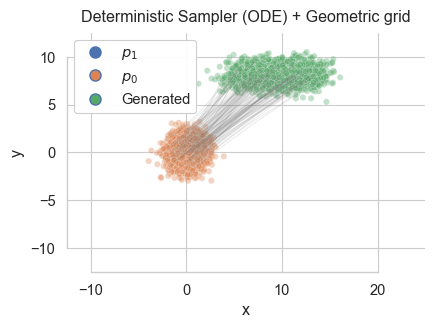

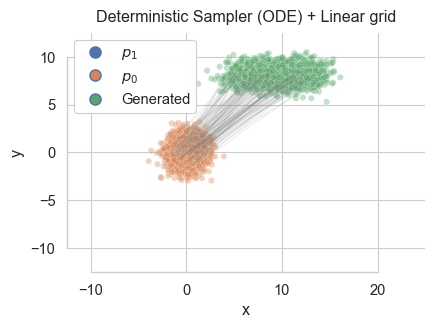

In [148]:
j = 2

fig_geom = draw_plot_sns(traj1_geom.trajectories, D1, second_coord= j, M=25, num_traj=100,
                     sampler_label='Deterministic Sampler (ODE) + Geometric grid', save_pdf=False)
fig_lin = draw_plot_sns(traj1_lin.trajectories, D1, second_coord= j, M=25, num_traj=100,
                     sampler_label='Deterministic Sampler (ODE) + Linear grid', save_pdf=False)

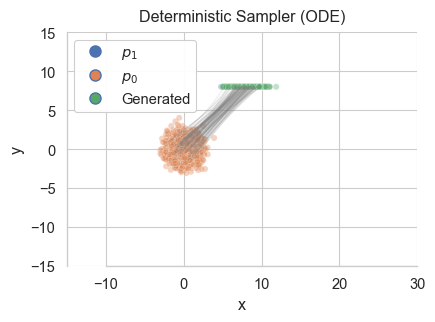

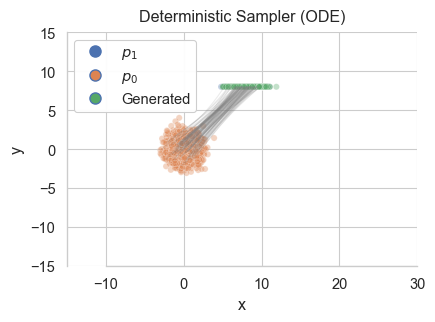

In [100]:
true_euler_sampler_lin = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
    rectified_flow=straight_rf,
    time_grid = lin_timegrid_generator(NUM_STEPS),
    num_samples= NUM_SAMPLES,
)

true_euler_sampler_geom = MytrueEulerSampler( k = RANK, d = INPUT_DIM, CENTER= CENTER,
    rectified_flow=straight_rf,
    time_grid = geom_timegrid_generator(NUM_STEPS),
    num_samples= NUM_SAMPLES,
)

true_traj1_geom = true_euler_sampler_geom.sample_loop(seed=100)
true_traj1_lin = true_euler_sampler_lin.sample_loop(seed=100)

fig_geom = draw_plot_sns(true_traj1_geom.trajectories, D1,  second_coord=j, M=30, num_traj=100,
                     sampler_label='Deterministic Sampler (ODE)', save_pdf=False)
fig_lin = draw_plot_sns(true_traj1_lin.trajectories, D1, second_coord=j, M=30, num_traj=100,
                     sampler_label='Deterministic Sampler (ODE)', save_pdf=False)

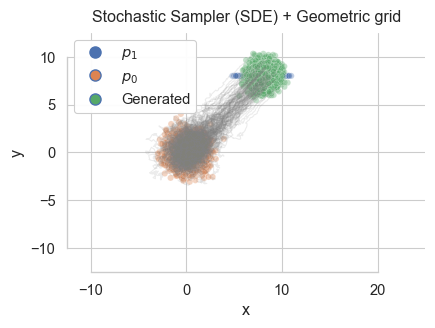

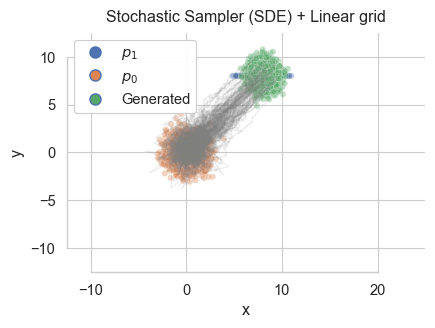

In [101]:
j = 9

fig_geom = draw_plot_sns(traj2_geom.trajectories, D1, second_coord= j, M=25, num_traj=100,
                     sampler_label='Stochastic Sampler (SDE) + Geometric grid', save_pdf=False)
fig_lin = draw_plot_sns(traj2_lin.trajectories, D1, second_coord= j, M=25, num_traj=100,
                     sampler_label='Stochastic Sampler (SDE) + Linear grid', save_pdf=False)

In [56]:
true_traj1_geom.trajectories[-1].mean(dim=0), true_traj1_geom.trajectories[-1].std(dim=0)

(tensor([7.9944, 8.0110, 8.0025, 7.9975, 8.0637, 8.0160, 8.0105, 7.9921, 8.0000,
         8.0000]),
 tensor([0.9775, 0.9737, 0.9898, 1.0038, 0.9950, 1.0172, 0.9984, 0.9883, 0.0000,
         0.0000]))

In [102]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.metrics import accuracy_score


def calculate_discriminative_tv_qda(real_data, generated_data):
    """
    Estimates the Total Variation (TV) Distance using the Bayes Optimal 
    Classifier (QDA) for Gaussian data, as an empirical approximation 
    of the Bayes Risk (R_star).
    
    TV(P, Q) ≈ 1 - 2 * R_hat, where R_hat is the QDA test error.
    
    Args:
        real_data (np.ndarray): Samples from the real distribution (P).
        generated_data (np.ndarray): Samples from the generated distribution (Q).
        
    Returns:
        float: Estimated Total Variation Distance (TVD).
    """
    # 1. Prepare Data for Classification
    
    # Label 1 for Real data, Label 0 for Generated data
    X = np.concatenate([real_data, generated_data])
    y = np.concatenate([np.ones(len(real_data)), np.zeros(len(generated_data))])
    
    # Use a large test size for a robust estimation of the test error
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.5, random_state=42, stratify=y
    )
    
    # 2. Train the Bayes Optimal Classifier (QDA)
    # QDA is the optimal classifier when data is Gaussian, even with different covariances.
    try:
        # Note: QDA fits the mean and covariance for each class from the training data.
        classifier = QDA()
        classifier.fit(X_train, y_train)
        
        # 3. Calculate the Classification Error (Risk, R_hat) on the test set
        y_pred = classifier.predict(X_test)
        
        # Accuracy is 1 - Error Rate (Risk)
        accuracy = accuracy_score(y_test, y_pred)
        risk_R_hat = 1.0 - accuracy
        
        # 4. Estimate TV Distance
        # TV(P, Q) = 1 - 2 * R_hat
        estimated_tv_distance = 1.0 - 2 * risk_R_hat
        
        # Clamp the result to the valid [0, 1] range for TV distance
        return max(0.0, min(1.0, estimated_tv_distance))
    
    except ValueError as e:
        print(f"Error training classifier: {e}")
        return np.nan

# --- Example Usage ---

time_grid = geom_timegrid_generator(NUM_STEPS)
pos  = 2  # Position in the time grid to evaluate
Real_Data = D1[:NUM_SAMPLES] * time_grid[-pos] + torch.randn_like(D1[:NUM_SAMPLES]) * (1 - time_grid[-pos])
Real_Data = Real_Data.cpu().numpy()  # Real data samples from distribution p_1
Gen_Data_geom = true_traj1_geom.trajectories[-pos].cpu().numpy()  # Generated data samples from geometry time grid
Gen_Data_lin = true_traj1_lin.trajectories[-pos].cpu().numpy()  # Generated data samples from linear time grid
tv_qda_geom = calculate_discriminative_tv_qda(Real_Data, Gen_Data_geom)
tv_qda_lin = calculate_discriminative_tv_qda(Real_Data, Gen_Data_lin)
print(f"Estimated TV Distance (Geometry Time Grid): {tv_qda_geom:.4f}")
print(f"Estimated TV Distance (Linear Time Grid): {tv_qda_lin:.4f}")

Estimated TV Distance (Geometry Time Grid): 0.0000
Estimated TV Distance (Linear Time Grid): 0.0000


In [105]:
np.linalg.norm(np.mean(Real_Data, axis=0) - np.mean(Gen_Data_geom, axis=0)), np.linalg.norm(np.mean(Real_Data, axis=0) - np.mean(Gen_Data_lin, axis=0))

(0.09861727, 0.098992996)

In [86]:
# Frobenius norm of covariance matrices
print(f"Frobenius norm of difference between real and generated data cov matrices (Geom): {np.linalg.norm(np.cov(Real_Data, rowvar=False) - np.cov(Gen_Data_geom, rowvar=False), ord='fro')}")
print(f"Frobenius norm of difference between real and generated data cov matrices (Lin): {np.linalg.norm(np.cov(Real_Data, rowvar=False) - np.cov(Gen_Data_lin, rowvar=False), ord='fro')}")

Frobenius norm of difference between real and generated data cov matrices (Geom): 0.2729275357220816
Frobenius norm of difference between real and generated data cov matrices (Lin): 0.27469365175438404


In [103]:
# KL distance between Real data and generated data which are gaussian
mean_real = np.mean(Real_Data, axis=0)
cov_real = np.cov(Real_Data, rowvar=False)
mean_gen_geom = np.mean(Gen_Data_geom, axis=0)
cov_gen_geom = np.cov(Gen_Data_geom, rowvar=False)
mean_gen_lin = np.mean(Gen_Data_lin, axis=0)
cov_gen_lin = np.cov(Gen_Data_lin, rowvar=False)

def kl_divergence_gaussians(mean_p, cov_p, mean_q, cov_q):
    """
    Calculate the KL divergence D_KL(P || Q) between two multivariate Gaussian distributions P and Q.
    
    Args:
        mean_p (np.ndarray): Mean vector of distribution P.
        cov_p (np.ndarray): Covariance matrix of distribution P.
        mean_q (np.ndarray): Mean vector of distribution Q.
        cov_q (np.ndarray): Covariance matrix of distribution Q.        
    """
    d = mean_p.shape[0]
    cov_q_inv = np.linalg.inv(cov_q)
    
    term1 = np.trace(cov_q_inv @ cov_p)
    term2 = (mean_q - mean_p).T @ cov_q_inv @ (mean_q - mean_p)
    sign_q, abslogdet_q = np.linalg.slogdet(cov_q)
    sign_p, abslogdet_p = np.linalg.slogdet(cov_p)
    term3 = sign_q * abslogdet_q - sign_p * abslogdet_p
    #term3 = np.log(np.linalg.det(cov_q) / np.linalg.det(cov_p) + 1e-10)  # Added small constant for numerical stability
    
    kl_div = 0.5 * (term1 + term2 - d + term3)
    return kl_div

print(f"KL Divergence (Geom): {kl_divergence_gaussians(mean_real, cov_real, mean_gen_geom, cov_gen_geom)}")
print(f"KL Divergence (Lin): {kl_divergence_gaussians(mean_real, cov_real, mean_gen_lin, cov_gen_lin)}")    


KL Divergence (Geom): 26.829545624031823
KL Divergence (Lin): 26.82048869901601


In [71]:
len(time_grid)

81

In [58]:
np.std(Gen_Data_geom, axis = 0), np.std(Gen_Data_lin, axis = 0)

(array([0.97534955, 0.97153014, 0.9875458 , 1.0015072 , 0.99273103,
        1.0149337 , 0.99619365, 0.9861228 , 0.00198431, 0.00203674],
       dtype=float32),
 array([0.98180854, 0.9779641 , 0.9940864 , 1.00814   , 0.99930555,
        1.0216552 , 1.0027909 , 0.99265337, 0.00198423, 0.00203666],
       dtype=float32))

In [81]:
np.cov(Gen_Data_lin, rowvar=False)

array([[ 1.03485107e+00, -4.84707744e-03, -6.52960652e-03, ...,
        -1.96926049e-05, -5.55568261e-05, -2.82938003e-05],
       [-4.84707744e-03,  1.01036216e+00, -5.05688996e-03, ...,
        -3.29916453e-05,  4.10234280e-05,  6.80117846e-05],
       [-6.52960652e-03, -5.05688996e-03,  9.91930974e-01, ...,
        -6.02760378e-05, -7.23664370e-06,  7.80676446e-05],
       ...,
       [-1.96926049e-05, -3.29916453e-05, -6.02760378e-05, ...,
         4.16147548e-06, -8.82112295e-08,  8.43960562e-08],
       [-5.55568261e-05,  4.10234280e-05, -7.23664370e-06, ...,
        -8.82112295e-08,  3.94523837e-06, -9.53876203e-09],
       [-2.82938003e-05,  6.80117846e-05,  7.80676446e-05, ...,
         8.43960562e-08, -9.53876203e-09,  4.22440109e-06]])

In [82]:
np.cov(Gen_Data_geom, rowvar=False)

array([[ 1.02127929e+00, -4.78377327e-03, -6.44388067e-03, ...,
        -1.95805597e-05, -5.52100426e-05, -2.80930599e-05],
       [-4.78377327e-03,  9.97111461e-01, -4.99063690e-03, ...,
        -3.27728872e-05,  4.07792450e-05,  6.75688557e-05],
       [-6.44388067e-03, -4.99063690e-03,  9.78921319e-01, ...,
        -5.98739794e-05, -7.18086028e-06,  7.75543717e-05],
       ...,
       [-1.95805597e-05, -3.27728872e-05, -5.98739794e-05, ...,
         4.16174033e-06, -8.81479413e-08,  8.44992050e-08],
       [-5.52100426e-05,  4.07792450e-05, -7.18086028e-06, ...,
        -8.81479413e-08,  3.94556903e-06, -9.54176246e-09],
       [-2.80930599e-05,  6.75688557e-05,  7.75543717e-05, ...,
         8.44992050e-08, -9.54176246e-09,  4.22474078e-06]])

In [162]:
#np.cov(Real_Data, rowvar=False)
d = 256 * 256; N = 80
d**2/N**10

4e-10